# Lab01: Data Wrangling and EDA 
## Part 1: Initial Analysis of Foreign Gifts recieved by academic institutuions in the US.

## 1. Load the Data

In [4]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px

foreign_gifts= pd.read_csv("data/ForeignGifts_edu.csv")
foreign_gifts.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


### Data Inspoection

In [5]:
print("Dimensions:",foreign_gifts.shape)
# print(foreign_gifts.describe())
print(foreign_gifts.info())

Dimensions: (28221, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28221 entries, 0 to 28220
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          28221 non-null  int64 
 1   OPEID                       28221 non-null  int64 
 2   Institution Name            28221 non-null  object
 3   City                        28221 non-null  object
 4   State                       28221 non-null  object
 5   Foreign Gift Received Date  28221 non-null  int64 
 6   Foreign Gift Amount         28221 non-null  int64 
 7   Gift Type                   28221 non-null  object
 8   Country of Giftor           28221 non-null  object
 9   Giftor Name                 24470 non-null  object
dtypes: int64(4), object(6)
memory usage: 2.2+ MB
None


### Inspection of Missing Values

In [6]:
foreign_gifts.isna().sum()

ID                               0
OPEID                            0
Institution Name                 0
City                             0
State                            0
Foreign Gift Received Date       0
Foreign Gift Amount              0
Gift Type                        0
Country of Giftor                0
Giftor Name                   3751
dtype: int64

### Upon inspection of the questions filtering data frame to contain only the required columns for analysis

In [7]:
fg = foreign_gifts[['ID', 'Institution Name','State', 'Foreign Gift Amount', 'Gift Type', 'Country of Giftor','Giftor Name']]
fg.head()

,ID,Institution Name,State,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,Jacksonville State University,AL,250000,Monetary Gift,CHINA,NaN
1,2,Troy University,AL,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,University of Alabama,AL,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,University of Alabama,AL,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,University of Alabama,AL,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


## 2. Describe the differences between different classes of gift types?

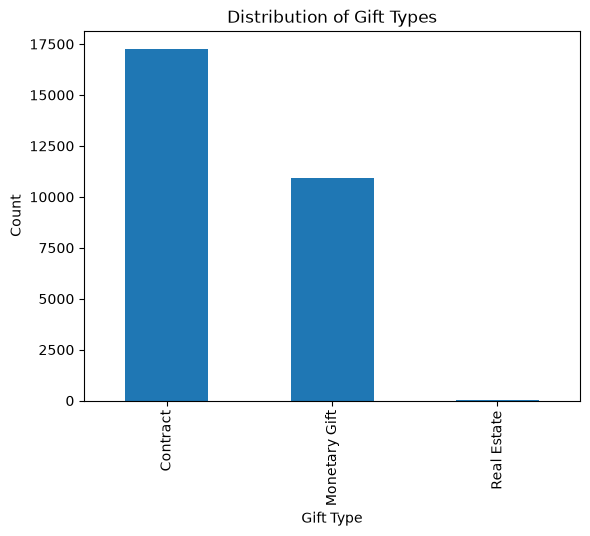

In [8]:
gift_types = fg["Gift Type"].value_counts()
gift_types.plot(kind="bar")
plt.title("Distribution of Gift Types")
plt.xlabel("Gift Type")
plt.ylabel("Count")
plt.show()

In [9]:
gift_type_amounts = fg.groupby("Gift Type")["Foreign Gift Amount"].agg(['count', 'sum','mean', 'median']) 
gift_type_amounts

,count,sum,mean,median
Gift Type,,,,
Contract,17274,10809974431,6.257945e+05,110000.0
Monetary Gift,10936,5775853163,5.281504e+05,50000.0
Real Estate,11,14687920,1.335265e+06,667555.0


### Analysis

There are three different types of gift types in the data given.
**Contarct, Monetary Gift, Real estate**
**Statistical highlights**
**Contract**: Contracts are highest form in which the gifts are recieved and accounts for the largest sum recieved as well.
**Real Estate**: Real estate gift are rare but interestingly have the highest average amongst all gift sizes due to the assumption that the resources prorate for any real estate funding expenses.
**Monetary Gifts**: These are the second highest form of gifts recieved with a drastically lower median showing some institutions have recieved relatively larger monetary funds.



## Questions:

<div class="alert alert-block alert-warning">
<b>Question 1: Which country gives the most money in total?</b>
</div>

### Answer: = Country: Qatar  Amount:$2706240869

In [10]:
country_total = fg.groupby("Country of Giftor")['Foreign Gift Amount'].sum().sort_values(ascending=False)
# print("Answer: The country which gives the most money in total is:", country_total.head(1))
print(country_total.head())
print(f"The country which gives the most money in total is: {country_total.idxmax()}, which is  ${country_total.max():.2f}")


Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
Name: Foreign Gift Amount, dtype: int64
The country which gives the most money in total is: QATAR, which is  $2706240869.00


<div class="alert alert-block alert-warning">
<b>Question 2: Which country initiates the most gifts by count?</b>
</div>

### Answer: Country: Engalnd Gifts: 3655

In [11]:
highest_giftors = fg.groupby("Country of Giftor")["Foreign Gift Amount"].count().sort_values(ascending=False)
print(highest_giftors.head())
print(f"The country with the most giftors is: {highest_giftors.idxmax()}, with {highest_giftors.max()} gifts")

Country of Giftor
ENGLAND        3655
CHINA          2461
CANADA         2344
JAPAN          1896
SWITZERLAND    1676
Name: Foreign Gift Amount, dtype: int64
The country with the most giftors is: ENGLAND, with 3655 gifts


<div class="alert alert-block alert-warning">
<b>Question 3: Which country gives the largest gifts on average?</b>
</div>

### Answer: Country: Bermuda Largest gift average $7688837.37

In [12]:
largest_gift_avg = fg.groupby("Country of Giftor")["Foreign Gift Amount"].mean().sort_values(ascending=False)
print(largest_gift_avg.head())
print(f"The country with the largest average foreign gift amount is: {largest_gift_avg.idxmax()}, which is  ${largest_gift_avg.max():.2f}")

Country of Giftor
BERMUDA    7.688837e+06
ECUADOR    3.985140e+06
QATAR      3.905109e+06
ANTIGUA    3.435545e+06
JERSEY     3.064589e+06
Name: Foreign Gift Amount, dtype: float64
The country with the largest average foreign gift amount is: BERMUDA, which is  $7688837.37


<div class="alert alert-block alert-warning">
<b>Question 4: Which institution receive the most money in total?</b>
</div>

### Answer: Carnegie Mellon University, which is  $1477922504.00

In [13]:
institution_total = fg.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(20)
print(institution_total.head())
print(f"The institution which receives the most money in total is: {institution_total.idxmax()}, which is  ${institution_total.max():.2f}")


Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
Name: Foreign Gift Amount, dtype: int64
The institution which receives the most money in total is: Carnegie Mellon University, which is  $1477922504.00


<div class="alert alert-block alert-warning">
<b>Question 5: Which institution receive the greatest number of gifts by count?</b>
</div>

### Answer: University of California, Los Angeles, with 3916 gifts

In [14]:
institution_recieved = fg['Institution Name'].value_counts().sort_values(ascending=False)
print(institution_recieved.head())
print(f"The institution which receives the most foreign gifts is: {institution_recieved.idxmax()}, with {institution_recieved.max()} gifts")

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
Name: count, dtype: int64
The institution which receives the most foreign gifts is: University of California, Los Angeles, with 3916 gifts


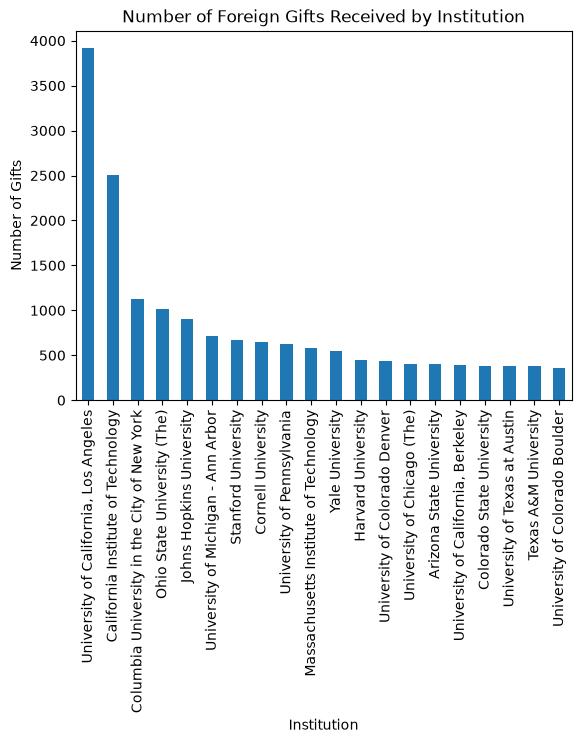

In [15]:
top20 = institution_recieved.head(20)
top20.plot(kind="bar")
plt.title("Number of Foreign Gifts Received by Institution")
plt.xlabel("Institution")
plt.ylabel("Number of Gifts")
plt.show()

<div class="alert alert-block alert-warning">
<b>Question 6: What is the average amount each university receives? Median amount? If they are different why?</b>
</div>

### Answer: 
**Mean gift amount received by institutions: $52202878.97**
**Median gift amount received by institutions: $6486791.5**

The mean is exceptionally higher than the median for all gift amounts due to larger to goift amounts to some institutiuons pulling the average up. However this average does not provide a fair idea about the distribution of the gift amounts better than median as some institutions are favoured over the rest. Due to the larger donations and gifts to some institutions the data is right skewed due to which there is a stark difference between the mean and the median.


In [16]:
total = fg.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending=False)
mean_total = total.mean().round(2)
median_total = total.median()
print(f"Mean gift amount received by institutions: ${mean_total}")
print(f"Median gift amount received by institutions: ${median_total}")

Mean gift amount received by institutions: $52202878.97
Median gift amount received by institutions: $6486791.5


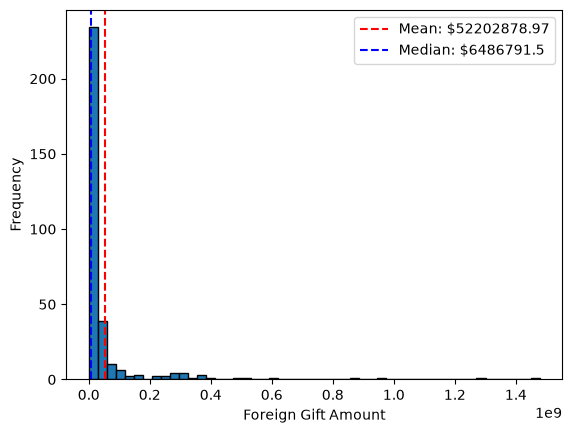

In [17]:
plt.hist(total, bins=50, edgecolor='black')
plt.axvline(mean_total, color='red', linestyle='--',label=f"Mean: ${mean_total}")
plt.axvline(median_total, color='blue', linestyle='--',label=f"Median: ${median_total}")
plt.legend()
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Frequency")
plt.show()

<div class="alert alert-block alert-warning">
<b>Question 7: What is the largest flow of a single country to a single institution?</b>
</div>

### Answer: The country with the largest flow to an institution is from Qatar to Carnegie Melon University

In [18]:
flow = fg.groupby(["Country of Giftor", "Institution Name"])["Foreign Gift Amount"].sum().sort_values(ascending=False)
flow.head()
print("The country that gives the most money to an institution is: ", flow.idxmax(), "with ", flow.max())

The country that gives the most money to an institution is:  ('QATAR', 'Cornell University') with  1018473315


In [25]:
flow_ct = pd.crosstab(fg['Country of Giftor'],fg['Institution Name'],values =fg['Foreign Gift Amount'], aggfunc='sum')
flow_ct.loc[flow_ct.max(axis=1).sort_values(ascending=False).index].head()

Institution Name,Adelphi University,Albert Einstein College of Medicine,Alfred University,American University (The),Amherst College,Arizona State University,Auburn University Montgomery,Babson College,Ball State University,Barnard College,...,Wilkes University,William Marshall Rice University,Williams College,Winthrop University,Worcester Polytechnic Institute,Wright State University,Xavier University of Louisiana,Yale University,Yeshiva University,Young Americans College of the Performing Arts (The)
Country of Giftor,,,,,,,,,,,,,,,,,,,,,
QATAR,NaN,NaN,NaN,NaN,NaN,2515184.0,NaN,NaN,NaN,NaN,...,NaN,252896.0,NaN,NaN,NaN,NaN,NaN,284668.0,NaN,NaN
BERMUDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,76800000.0,NaN,NaN,NaN,NaN,NaN,1002500.0,NaN,NaN
CANADA,NaN,NaN,NaN,NaN,NaN,28846617.0,NaN,330401.0,NaN,NaN,...,NaN,294190.0,NaN,NaN,NaN,NaN,NaN,11484325.0,297397.0,NaN
UNITED ARAB EMIRATES,NaN,NaN,NaN,NaN,NaN,9772808.0,NaN,NaN,NaN,NaN,...,NaN,12538800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENGLAND,NaN,1064580.0,NaN,2000000.0,NaN,NaN,NaN,1052823.0,NaN,1825000.0,...,NaN,4272116.0,NaN,NaN,NaN,NaN,NaN,107303970.0,NaN,NaN


In [119]:
import plotly.graph_objects as go

# giftor = 'Giftor Name'
# recipi = 'Institution Name'
# flor = 'Foreign Gift Amount'

giftor = 'Giftor Name'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    fg.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()



<div class="alert alert-block alert-warning">
<b>Question 8: Which are the top giftors to US academic institutions?</b>
</div>

### Answer: The top 5 giftors to US academic institutions are Qatar foundation, Qatar Foundation/Qatar National Res,Qatar Foundation for Education, Anonymous and saudi Arabian Cultural Mission

In [120]:
top_giftors =fg.groupby(["Giftor Name"])["Foreign Gift Amount"].sum().sort_values(ascending=False)
top_giftors.head()

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
Name: Foreign Gift Amount, dtype: int64

# Key Points from Initial Analysis

1. England has the highest number of gifts, indicating that it has the highest gifting frequency among the countries represented in the dataset.

2. Qatar, despite having fewer gifts than England, represents the largest source of gifts by total dollar amount. This suggests that the gifts from Qatar tend to be substantially larger in value.

3. Bermuda has the highest average gift amount.However, this appears to be influenced by a single unusually large donation, making the average potentially misleading and not necessarily representative of typical gifts from Bermuda.

4. Carnegie Mellon University receives the highest total gift amount by dollars among the institutions in the dataset.

5. A common pattern across the analyses is that a small number of very large individual donations, particularly to private schools, can significantly skew the dataset. These large donations make it difficult to understand the underlying distribution and typical size of the remaining gifts. A more accurate comparison of the share and distribution of gifts between public and private schools would require additional filtering and normalization of the Foreign Gift Amount variable, which is beyond the scope of this analysis.
